Cargando anotaciones...


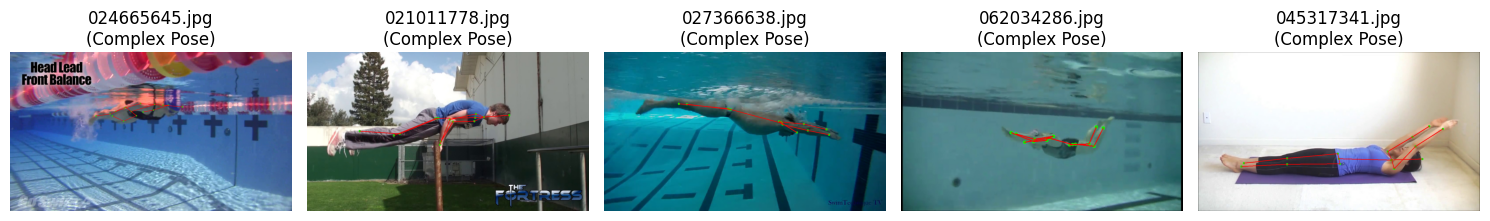

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat

# resultados de imagenes
target_images = [
    '024665645.jpg', '021011778.jpg', '027366638.jpg', 
    '062034286.jpg', '045317341.jpg'
]

IMG_FOLDER = 'images'
MAT_FILE = 'mpii_human_pose_v1_u12_1.mat'

# pares de articulaciones para dibujar el esqueleto
SKELETON_PAIRS = [
    (0,1), (1,2), (2,6),       # Pierna Der -> Cadera
    (3,4), (4,5), (3,6),       # Pierna Izq -> Cadera
    (6,7), (7,8), (8,9),       # Columna -> Cabeza
    (10,11), (11,12), (12,8),  # Brazo Izq -> Pecho
    (13,14), (14,15), (13,8)   # Brazo Der -> Pecho
]

def get_joints(filename, annolist):
    # buscar la imagen en el .mat
    for img in annolist:
        try:
            name = img['image'][0,0]['name'][0]
            if name == filename:
                rects = img['annorect']
                if rects.ndim > 1: rects = rects.flatten()
                
                # retornar los puntos de la primera persona con puntos válidos
                for r in rects:
                    if 'annopoints' in r.dtype.names and r['annopoints'].size > 0:
                        pts_wrap = r['annopoints'].flatten()[0]
                        if 'point' in pts_wrap.dtype.names:
                            return pts_wrap['point'].flatten()
        except:
            continue
    return None

print("Cargando anotaciones...")
mat = loadmat(MAT_FILE)
annolist = mat['RELEASE']['annolist'][0, 0][0]

plt.figure(figsize=(15, 5))

for i, img_name in enumerate(target_images):
    path = os.path.join(IMG_FOLDER, img_name)
    if not os.path.exists(path):
        print(f"Falta imagen: {path}")
        continue
        
    # cargar imagen BGR a RGB
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    joints = get_joints(img_name, annolist)
    
    if joints is not None:
        # dibujar puntos y líneas
        coords = {}
        for j in joints:
            id_ = j['id'][0,0]
            x = int(j['x'][0,0])
            y = int(j['y'][0,0])
            coords[id_] = (x, y)
            cv2.circle(img, (x, y), 5, (0, 255, 0), -1)
            
        for p1, p2 in SKELETON_PAIRS:
            if p1 in coords and p2 in coords:
                cv2.line(img, coords[p1], coords[p2], (255, 0, 0), 2)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"{img_name}\n(Complex Pose)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import os
import numpy as np
from scipy.io import loadmat

PATH_IMAGES_MPII = 'images'
OUTPUT_FOLDER = 'dataset_final'
PAD_FACTOR = 0.15

# carpetas de salida
os.makedirs(f"{OUTPUT_FOLDER}/positives_complex", exist_ok=True)
os.makedirs(f"{OUTPUT_FOLDER}/positives_standing", exist_ok=True)

def get_bbox(rect):
    # Devuelve (x, y, w, h) sanitizados a int estándar de Python 
    try:
        if 'annopoints' not in rect.dtype.names: return None
        ap = rect['annopoints']
        if ap.size == 0: return None
        
        ap_flat = ap.flatten()
        if ap_flat.size == 0: return None
        
        points_struct = ap_flat[0]
        if 'point' not in points_struct.dtype.names: return None
        
        points = points_struct['point']
        if points.size == 0: return None
        
        flat_points = points.flatten()
        xs = []
        ys = []
        
        for p in flat_points:
            if p['x'].size > 0 and p['y'].size > 0:
                xs.append(int(p['x'].flat[0]))
                ys.append(int(p['y'].flat[0]))
        
        if not xs: return None
        
        # Calcular caja base
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        w = x_max - x_min
        h = y_max - y_min
        
        if w < 5 or h < 5: return None
        
        return (x_min, y_min, w, h)
        
    except Exception as e:
        return None

# --- CARGA ---
print("Cargando anotaciones .mat...")
mat = loadmat('mpii_human_pose_v1_u12_1.mat')
dataset = mat['RELEASE']['annolist'][0, 0][0] 

count_complex = 0
count_standing = 0

print(f"Procesando {len(dataset)} imágenes y exportando recortes...")

for i, img in enumerate(dataset):
    if i % 1000 == 0:
        print(f"--> Procesadas: {i} | Complejas: {count_complex} | De Pie: {count_standing}")

    # validaciones
    if 'annorect' not in img.dtype.names or img['annorect'].size == 0: continue
    try:
        name = img['image'][0,0]['name'][0]
    except: continue

    # leer imagen original
    img_path = os.path.join(PATH_IMAGES_MPII, name)
    original_img = cv2.imread(img_path)
    
    if original_img is None:
        continue # Si no encuentra la imagen salta

    img_h, img_w = original_img.shape[:2]

    # Procesar rectángulos
    rects = img['annorect']
    if rects.ndim > 1: rects = rects.flatten()
    
    for person_idx, person_rect in enumerate(rects):
        bbox = get_bbox(person_rect)
        
        if bbox:
            x, y, w, h = bbox
            ratio = h / w

            # aplicar padding
            pad_x = int(w * PAD_FACTOR)
            pad_y = int(h * PAD_FACTOR)
            
            x1 = max(0, int(x - pad_x))
            y1 = max(0, int(y - pad_y))
            x2 = min(img_w, int(x + w + pad_x))
            y2 = min(img_h, int(y + h + pad_y))
            
            # Recortar
            crop = original_img[y1:y2, x1:x2]
            
            if crop.size == 0: continue

            # guardar
            save_name = f"{name.split('.')[0]}_p{person_idx}.jpg"
            
            if 0.2 < ratio < 1.5:
                # Compleja
                cv2.imwrite(f"{OUTPUT_FOLDER}/positives_complex/{save_name}", crop)
                count_complex += 1
            elif ratio >= 1.5:
                # Vertical / De pie
                cv2.imwrite(f"{OUTPUT_FOLDER}/positives_standing/{save_name}", crop)
                count_standing += 1

print("\n" + "="*30)
print(f"EXPORTACIÓN FINALIZADA")
print(f"Imágenes en 'dataset_final/positives_complex': {count_complex}")
print(f"Imágenes en 'dataset_final/positives_standing': {count_standing}")
print("="*30)

Cargando anotaciones .mat (esto toma unos segundos)...
Procesando 24987 imágenes y exportando recortes...
--> Procesadas: 0 | Complejas: 0 | De Pie: 0
--> Procesadas: 1000 | Complejas: 309 | De Pie: 807
--> Procesadas: 2000 | Complejas: 614 | De Pie: 1551
--> Procesadas: 3000 | Complejas: 896 | De Pie: 2542
--> Procesadas: 4000 | Complejas: 1243 | De Pie: 3164
--> Procesadas: 5000 | Complejas: 1471 | De Pie: 3941
--> Procesadas: 6000 | Complejas: 1713 | De Pie: 4875
--> Procesadas: 7000 | Complejas: 2037 | De Pie: 5428
--> Procesadas: 8000 | Complejas: 2354 | De Pie: 6320
--> Procesadas: 9000 | Complejas: 2628 | De Pie: 7152
--> Procesadas: 10000 | Complejas: 2905 | De Pie: 8176
--> Procesadas: 11000 | Complejas: 3177 | De Pie: 9081
--> Procesadas: 12000 | Complejas: 3447 | De Pie: 9763
--> Procesadas: 13000 | Complejas: 3673 | De Pie: 10965
--> Procesadas: 14000 | Complejas: 3930 | De Pie: 11974
--> Procesadas: 15000 | Complejas: 4245 | De Pie: 13069
--> Procesadas: 16000 | Complejas: